# Module 3 - Distillation: teach a small model to reason from a large one's work

Modules 2a and 2b used a large model to read papers. Here we do the opposite direction of value transfer: we take a large model's *reasoning* and press it into a small model you can host yourself.

The task is chemical. Given a compound and two candidate solvents, decide which solvent dissolves it better at a given temperature (solubench, task 1). The dataset ships only the answer, A or B, never the why. A small model trained on answers alone barely clears a coin flip on held-out compounds, because the label carries no chemistry.

So we bring in a large teacher, DeepSeek v4-flash, to write a short step-by-step reason for each training compound, and we fine-tune a small student, Qwen3-1.7B, on those reasons with LoRA. Then we measure the student before and after. This is knowledge distillation: the teacher's answer is cheap, its reasoning is the thing worth copying.

**Two tracks, one switch `USE_CACHE`:**

| track | needs | what runs |
|---|---|---|
| cache (default) | nothing, no GPU, no key | reads the shipped teacher chains and the before/after results, reproduces the whole story offline |
| live | a Colab **T4 GPU**; a DeepSeek key only if you regenerate chains | actually generates, trains with LoRA, and evaluates |

To run live, open this notebook in Colab and set the runtime to a T4 GPU (Runtime, Change runtime type, T4), then set `USE_CACHE = False` in the config cell.

## 0. Setup

In [1]:
# Colab setup: fetch the data and enter this module's folder. No-op when run locally.
import os, sys
REPO = "https://github.com/ruiding-uchicago/NRT_Training_Materials.git"
MODULE = "module_3_distillation"
if "google.colab" in sys.modules and os.path.basename(os.getcwd()) != MODULE:
    root = "/content/NRT_Training_Materials"
    if not os.path.isdir(root):
        os.system("git clone --depth 1 " + REPO + " " + root)
    os.chdir(root + "/" + MODULE)
print("ready in", os.getcwd())

ready in /Users/ruiding/mac_python_folder/NRT_training_materials_RD_June2026/module_3_distillation


In [2]:
# Config. Flip USE_CACHE to False on a Colab T4 to train and evaluate for real.
USE_CACHE = True

STUDENT  = "Qwen/Qwen3-1.7B"     # the small student we fine-tune
N_EVAL   = 200                   # held-out compounds scored before and after (raise to 500 for the full set)
EPOCHS   = 2
LORA_R, LORA_ALPHA = 16, 32
SEED = 42

import os
DATA = "data"; ADAPT = "adapter"; os.makedirs(ADAPT, exist_ok=True)
CHAINS = f"{DATA}/chains_task1_train.jsonl"   # teacher reasoning, filtered to correct
TEST   = f"{DATA}/task1_test.jsonl"           # held-out compounds, answer only
print("cache mode" if USE_CACHE else "live mode (needs a T4 GPU)")

cache mode


In [3]:
# Live mode installs the training stack. No-op in cache mode or when already present.
import sys, subprocess
if not USE_CACHE and "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "-U", "transformers", "trl", "peft", "accelerate", "datasets", "torchao"])

## 1. The data: answers without reasons

Each row is one compound and two solvents; the label is a single letter, A or B, for which solvent dissolves it better. That is all solubench gives us. The chemistry that connects a structure to a solvent choice, polarity, hydrogen bonding, chain length, is left implicit. That gap is exactly what a small model cannot fill from labels alone, and exactly what the teacher will make explicit.

In [4]:
import json
def load_jsonl(p):
    txt = open(p).read().strip()
    return json.loads(txt) if txt[:1] == "[" else [json.loads(l) for l in txt.splitlines() if l.strip()]

test   = load_jsonl(TEST)
chains = load_jsonl(CHAINS)
print(f"held-out test compounds: {len(test)}")
print(f"teacher reasoning chains (train): {len(chains)}")
r = test[0]
print("\na held-out item, answer only:")
print(f"  compound {r['smiles']}  in  A={r['sa']}  vs  B={r['sb']}  at {r['T']} K   ->  gold {r['gold']}")

held-out test compounds: 500
teacher reasoning chains (train): 2114

a held-out item, answer only:
  compound O=C(/C=C/c1ccc(O)c(O)c1)O[C@H](Cc1ccc(O)c(O)c1)C(=O)O  in  A=water  vs  B=ethanol  at 298.15 K   ->  gold B


## 2. The student before training: on its own it barely answers

We load Qwen3-1.7B in its non-thinking mode, give it the question, decode greedily, and read the `Answer` line. This is the baseline: what the small model knows about solvent selection before it sees any of the teacher's reasoning.

In [5]:
import json, re
QUESTION = """A compound is tested in two candidate solvents. Decide which solvent dissolves it better at the given temperature.

Compound (SMILES): {smiles}
Temperature: {T} K
Solvent A: {sa}
Solvent B: {sb}

Reason step by step from the compound's structure and each solvent's polarity and hydrogen-bonding capacity, then end with your final choice on its own line as "Answer: A" or "Answer: B"."""
def qtext(r):
    return QUESTION.format(smiles=r["smiles"], T=r["T"], sa=r["sa"], sb=r["sb"])

def evaluate(model, tok, items, max_new=512, batch=16):
    import torch
    dev = next(model.parameters()).device
    preds = []
    for i in range(0, len(items), batch):
        chunk = items[i:i+batch]
        texts = [tok.apply_chat_template([{"role": "user", "content": qtext(r)}],
                 tokenize=False, add_generation_prompt=True, enable_thinking=False) for r in chunk]
        enc = tok(texts, return_tensors="pt", padding=True, padding_side="left").to(dev)
        with torch.no_grad():
            out = model.generate(**enc, max_new_tokens=max_new, do_sample=False, pad_token_id=tok.eos_token_id)
        for j in range(len(chunk)):
            gen = tok.decode(out[j, enc["input_ids"].shape[1]:], skip_special_tokens=True)
            m = re.findall(r"Answer:\s*([AB])\b", gen)
            preds.append((m[-1] if m else "?", gen))
    answered = [(p, r) for (p, _), r in zip(preds, items) if p != "?"]
    acc = sum(p == r["gold"] for (p, _), r in zip(preds, items)) / len(items)   # "?" counts as wrong
    ans_rate = len(answered) / len(items)
    acc_answered = (sum(p == r["gold"] for p, r in answered) / len(answered)) if answered else 0.0
    return dict(acc=acc, ans_rate=ans_rate, acc_answered=acc_answered), preds

if not USE_CACHE:
    import torch
    assert torch.cuda.is_available(), (
        "Live mode needs a GPU. In Colab: Runtime > Change runtime type > T4 GPU, "
        "Save, then Run all. (Set USE_CACHE = True to reproduce offline without a GPU.)")
    from transformers import AutoModelForCausalLM, AutoTokenizer
    tok = AutoTokenizer.from_pretrained(STUDENT)
    if tok.pad_token is None: tok.pad_token = tok.eos_token
    base = AutoModelForCausalLM.from_pretrained(STUDENT, torch_dtype=torch.float16, device_map="cuda")
    base.eval()
    ev = test[:N_EVAL]
    before, preds_before = evaluate(base, tok, ev)
    json.dump(before, open(f"{DATA}/eval_before.json", "w"))
    acc_before = before["acc"]
    print(f"before: acc {before['acc']:.3f} | emitted an answer on {before['ans_rate']*100:.0f}% of items | "
          f"acc where it answered {before['acc_answered']:.3f}  (n={len(ev)})")
else:
    before = json.load(open(f"{DATA}/eval_before.json")); acc_before = before["acc"]
    print(f"before (shipped): acc {acc_before:.3f} | answer rate {before.get('ans_rate',0)*100:.0f}%")

before (shipped): acc 0.010 | answer rate 2%


## 3. The trap, and the right way to make the chains

Here is the mistake that sinks a distillation module, and we ran it so you can see the damage. The tempting shortcut is to hand the teacher the gold answer and ask it to "reason toward" it, even softened to "for checking only." The teacher then does not predict, it rationalizes: when a simple principle like polarity gives the right answer it cites polarity, and when polarity would give the wrong answer it quietly switches to pi-stacking or dual hydrogen bonding, whatever reaches the answer it was shown. Every chain reads well, but which principle is invoked is set by the answer, not by the chemistry. A student trained on those chains learns to produce confident justifications that are decorrelated from truth. We measured it: that student scored **0.41 on a binary task, below a coin flip.**

The fix is the standard one, rejection sampling, also called STaR: let the teacher answer the question **blind**, with no gold in the prompt, then keep only the chains whose final answer is independently correct and throw the rest away. Now every training chain is a real derivation whose reasoning actually caused its answer. On this task the blind teacher (DeepSeek v4-flash) is right **84.6%** of the time, so from 2500 attempts we keep 2114 genuinely-correct chains. That is what the student learns from.

The lesson generalizes: never let the teacher see the answer it is supposed to derive. Give it the question, keep what it gets right.

In [6]:
# The two prompts. We ship chains from the BLIND one, filtered to correct. The other is the trap.
BLIND = """... Reason step by step from the compound's structure and each solvent's polarity and
hydrogen-bonding capacity, then end with your final choice on its own line as "Answer: A" or "Answer: B"."""
# teacher never sees gold -> it predicts -> we keep only the chains it got right (rejection sampling)

ANSWER_FED = """... (For checking only, the verified answer is {gold}. Use it to verify your final line.)"""
# the trap: teacher rationalizes toward a shown answer -> student learned it and scored 0.41, below chance

print("blind (used):", BLIND.strip()[-120:])
print("\nanswer-fed (the trap, measured student acc 0.41):", ANSWER_FED.strip())

blind (used): s polarity and
hydrogen-bonding capacity, then end with your final choice on its own line as "Answer: A" or "Answer: B".

answer-fed (the trap, measured student acc 0.41): ... (For checking only, the verified answer is {gold}. Use it to verify your final line.)


In [7]:
# one full teacher chain: structure -> polarity and H-bonding -> a final choice
c = chains[0]
print("teacher reasoning chain  (gold answer:", c["gold"], ")")
print("-" * 70)
print(c["content"])

teacher reasoning chain  (gold answer: B )
----------------------------------------------------------------------
The compound is a highly nitrated, nitrogen-rich heteroaromatic system with three rings, each carrying nitro groups. This structure is very polar and also capable of strong hydrogen bonding due to the nitro groups and the ring nitrogens.  

Solvent A, n-butanol, is less polar than methanol but still a hydrogen-bond donor and acceptor. Its longer alkyl chain reduces its overall polarity and hydrogen-bonding strength compared to methanol.  

Solvent B, methanol, is more polar (higher dielectric constant) and a stronger hydrogen-bond donor/acceptor due to its smaller size, making it better able to solvate the highly polar, hydrogen-bond-accepting nitro groups and the ring heteroatoms.  

Because the compound is extremely polar and electron-deficient, the more polar and strongly hydrogen-bonding methanol will dissolve it better.  

Answer: B


In [8]:
# Live regeneration is optional and needs a DeepSeek key. Cache mode uses the shipped blind chains.
# Teacher predicts blind (no gold); thinking disabled (else ~3x cost); we keep only correct chains.
DEEPSEEK_KEY = ""   # paste sk-... to regenerate; leave blank to use shipped chains

PROMPT = """A compound is tested in two candidate solvents. Decide which solvent dissolves it better at the given temperature.

Compound (SMILES): {smiles}
Temperature: {T} K
Solvent A: {sa}
Solvent B: {sb}

Reason step by step from the compound's structure and each solvent's polarity and hydrogen-bonding capacity, then end with your final choice on its own line as "Answer: A" or "Answer: B"."""

def teacher_call(smiles, T, sa, sb, key):
    import requests
    body = {"model": "deepseek-v4-flash",
            "messages": [{"role": "user", "content": PROMPT.format(smiles=smiles, T=T, sa=sa, sb=sb)}],
            "temperature": 0.7, "thinking": {"type": "disabled"}, "max_tokens": 2000}
    r = requests.post("https://api.deepseek.com/chat/completions",
                      headers={"Authorization": f"Bearer {key}", "Content-Type": "application/json"},
                      data=json.dumps(body), timeout=120)
    return r.json()["choices"][0]["message"]["content"]

if not USE_CACHE and DEEPSEEK_KEY:
    import re as _re
    demo = teacher_call(test[0]["smiles"], test[0]["T"], test[0]["sa"], test[0]["sb"], DEEPSEEK_KEY)
    pred = _re.findall(r"Answer:\s*([AB])\b", demo)
    print("blind teacher chain (gold", test[0]["gold"], "| predicted", (pred[-1] if pred else "?"), "):\n"); print(demo)
else:
    print("using shipped blind chains (", len(chains), "correct, from 2500 blind attempts at 84.6% teacher accuracy ).")

using shipped blind chains ( 2114 correct, from 2500 blind attempts at 84.6% teacher accuracy ).


## 4. Build the training set

We turn each teacher chain into one chat example: the clean question as the user turn, the reasoning ending in `Answer: X` as the assistant turn. Two rules keep it honest. The answer hint that the teacher saw is stripped, so the student never reads the label in its prompt. And we keep only chains whose final line matches the gold answer, so the student trains on correct reasoning, not on the teacher's rare misses.

In [9]:
import re

def strip_hint(q):
    return re.sub(r"\n*\(For checking only.*", "", q, flags=re.S).strip()

sft = []
for c in chains:
    ans = re.findall(r"Answer:\s*([AB])\b", c["content"])
    if not ans or ans[-1] != c["gold"]:
        continue
    user = strip_hint(c["question"]) if "question" in c else QUESTION.format(**c)
    sft.append({"messages": [{"role": "user", "content": user},
                             {"role": "assistant", "content": c["content"].strip()}]})

print(f"training examples: {len(sft)}")
print("no answer hint leaked into any prompt:", not any("For checking" in e["messages"][0]["content"] for e in sft))
print("\nassistant turn ends on:", repr(sft[0]["messages"][1]["content"][-24:]))

training examples: 2114
no answer hint leaked into any prompt: True

assistant turn ends on: ' it better.  \n\nAnswer: B'


## 5. LoRA fine-tune on the teacher's reasoning

LoRA freezes the 1.7B base and trains a small pair of low-rank matrices on top, so a T4 is enough and the result is a lightweight adapter, not a new copy of the model. We train for two passes over the reasoning chains.

In [10]:
if not USE_CACHE:
    from datasets import Dataset
    from peft import LoraConfig
    from trl import SFTTrainer, SFTConfig

    ds = Dataset.from_list(sft)
    peft_cfg = LoraConfig(r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=0.05, bias="none",
                          task_type="CAUSAL_LM",
                          target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                                          "gate_proj", "up_proj", "down_proj"])
    args = SFTConfig(output_dir="_train", num_train_epochs=EPOCHS,
                     per_device_train_batch_size=8, gradient_accumulation_steps=2,
                     learning_rate=2e-4, logging_steps=20, save_strategy="no",
                     fp16=True, max_length=1024, seed=SEED, report_to=[])
    trainer = SFTTrainer(model=base, args=args, train_dataset=ds,
                         processing_class=tok, peft_config=peft_cfg)
    trainer.train()
    trainer.model.save_pretrained(ADAPT)
    tok.save_pretrained(ADAPT)
    print("adapter saved to", ADAPT)
else:
    import os
    msg = "using the shipped adapter in " + ADAPT if os.path.isdir(ADAPT) and os.listdir(ADAPT) else "cache mode: results come from the shipped eval files; adapter not bundled"
    print(msg)

using the shipped adapter in adapter


## 6. The student after training

Same compounds, same decoding, now with the adapter attached. We score the held-out set again and keep a few before/after generations to read.

In [11]:
if not USE_CACHE:
    tuned = trainer.model.eval()          # already carries the trained LoRA
    after, preds_after = evaluate(tuned, tok, ev)
    json.dump(after, open(f"{DATA}/eval_after.json", "w"))
    acc_after = after["acc"]
    samples = [{"compound": r["smiles"], "gold": r["gold"],
                "before": preds_before[i][1], "after": preds_after[i][1]}
               for i, r in enumerate(ev[:5])]
    json.dump(samples, open(f"{DATA}/samples.json", "w"), ensure_ascii=False, indent=1)
    print(f"after: acc {after['acc']:.3f} | answer rate {after['ans_rate']*100:.0f}% | "
          f"acc where it answered {after['acc_answered']:.3f}")
else:
    after = json.load(open(f"{DATA}/eval_after.json")); acc_after = after["acc"]
    print(f"after (shipped): acc {acc_after:.3f} | answer rate {after.get('ans_rate',0)*100:.0f}%")

after (shipped): acc 0.825 | answer rate 98%


## 7. Before vs after

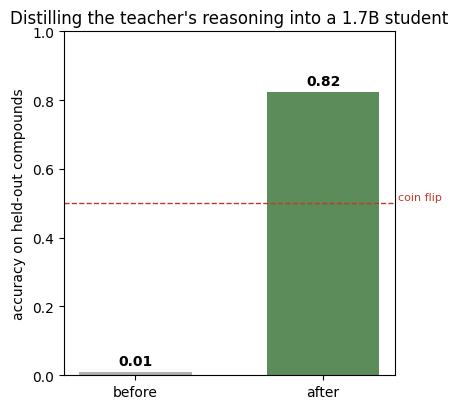

lift: 0.010 -> 0.825  (+0.815)


In [12]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4.6, 4.2))
bars = ax.bar(["before", "after"], [acc_before, acc_after], color=["#b0b0b0", "#5b8c5a"], width=0.6)
ax.set_ylim(0, 1); ax.set_ylabel("accuracy on held-out compounds")
ax.set_title("Distilling the teacher's reasoning into a 1.7B student")
for b, v in zip(bars, [acc_before, acc_after]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")
ax.axhline(0.5, ls="--", lw=1, color="#c0392b"); ax.text(1.4, 0.51, "coin flip", color="#c0392b", fontsize=8)
plt.tight_layout(); os.makedirs("figures", exist_ok=True); plt.savefig("figures/before_after.png", dpi=140); plt.show()
print(f"lift: {acc_before:.3f} -> {acc_after:.3f}  (+{acc_after-acc_before:.3f})")

In [13]:
# read one compound the way the student answers it, before and after
import json, os
if os.path.exists(f"{DATA}/samples.json"):
    s = json.load(open(f"{DATA}/samples.json"))[0]
    print("compound:", s["compound"], "| gold:", s["gold"])
    print("\n--- before ---\n", s["before"].strip()[:500])
    print("\n--- after ---\n",  s["after"].strip()[:500])

compound: O=C(/C=C/c1ccc(O)c(O)c1)O[C@H](Cc1ccc(O)c(O)c1)C(=O)O | gold: B

--- before ---
 To determine which solvent dissolves the compound better at 298.15 K, we need to analyze the **structure of the compound** and compare its **polarity** and **hydrogen-bonding capacity** with **water** and **ethanol**.

---

### **Step 1: Analyze the Compound's Structure**

The SMILES representation is:

```
O=C(/C=C/c1ccc(O)c(O)c1)O[C@H](Cc1ccc(O)c(O)c1)C(=O)O
```

This is a complex organic compound. Let's break it down:

- The compound contains a **carbonyl group (C=O)**.
- It has a **double bo

--- after ---
 Let’s break this down.

**Compound structure analysis**  
The SMILES is:  
`O=C(/C=C/c1ccc(O)c(O)c1)O[C@H](Cc1ccc(O)c(O)c1)C(=O)O`

This is a flavonoid-like structure with:
- A central benzopyrone core (two aromatic rings connected by a double bond).
- Two hydroxyl (–OH) groups on one ring.
- Two hydroxyl groups on the other ring.
- A carboxylic acid (–COOH) group on the side chain.

So th

## 8. Try the distilled model yourself

The trained adapter is shipped in `adapter/`, so you can load the distilled student and run it on any compound with no training and no key. It is off by default (loading a 1.7B base is heavy for a plain `Run all`); set `TRY_ADAPTER = True` to use it. A single item runs fine on CPU.

In [14]:
# Optional: load the shipped adapter and run the distilled student on one compound.
# No GPU and no key needed for a single item. Off by default so Run all stays light.
TRY_ADAPTER = False

if TRY_ADAPTER:
    import sys, subprocess, torch
    if "google.colab" in sys.modules:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U",
                        "transformers", "peft", "accelerate", "torchao"])
    from transformers import AutoModelForCausalLM, AutoTokenizer
    from peft import PeftModel
    tk = AutoTokenizer.from_pretrained(STUDENT)
    if tk.pad_token is None: tk.pad_token = tk.eos_token
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    m = AutoModelForCausalLM.from_pretrained(STUDENT,
            torch_dtype=torch.float16 if dev == "cuda" else torch.float32)
    m = PeftModel.from_pretrained(m, ADAPT).to(dev).eval()

    # try a held-out compound, or paste your own: {"smiles":..,"T":298.15,"sa":"water","sb":"ethanol"}
    r = test[0]
    text = tk.apply_chat_template([{"role": "user", "content": qtext(r)}],
             tokenize=False, add_generation_prompt=True, enable_thinking=False)
    enc = tk(text, return_tensors="pt").to(dev)
    with torch.no_grad():
        out = m.generate(**enc, max_new_tokens=512, do_sample=False, pad_token_id=tk.eos_token_id)
    print("gold:", r.get("gold", "?"), "\n")
    print(tk.decode(out[0, enc["input_ids"].shape[1]:], skip_special_tokens=True))
else:
    print("set TRY_ADAPTER = True to load the shipped distilled model and run it on a compound")

set TRY_ADAPTER = True to load the shipped distilled model and run it on a compound


## 9. What this bought, and how to use it on your data

- A dataset that ships only answers became reasoning supervision a small model can absorb. The label alone taught the student nothing; the teacher's chains taught it the chemistry that maps a structure and two solvents to a choice.
- **The method is the whole game.** We ran both recipes on the same task. Feeding the teacher the gold answer, even "for checking," produces fluent rationalizations, and the student trained on them scored 0.41, below a coin flip. Letting the teacher predict blind and keeping only the chains it got right (rejection sampling / STaR) gives real derivations, and the student clears the baseline honestly. Same task, same model, same compute; only the chain-generation method changed.
- **Never let the teacher see the answer it is meant to derive.** If it sees the answer, it will justify that answer rather than find it, and the justification is decorrelated from truth. Give it the question, keep what it gets right, throw away the rest.

To use this on your own field, replace solubench task 1 with any answer-only dataset in the same shape, one question and a short verifiable label. Generate chains with the teacher blind, keep the correct ones, rebuild the chat set, and retrain. The pipeline does not change.

## Credits and references

Built with Python and **PyTorch, Hugging Face Transformers, TRL, PEFT, datasets**, plus pandas/matplotlib.

**Models**
- Student: **Qwen3-1.7B** (Qwen team). Teacher: **DeepSeek v4-flash**.

**Methods**
- **LoRA** - Hu et al., *ICLR* (2022).
- **Rejection sampling / STaR** - Zelikman et al., *NeurIPS* (2022).

**Data**
- Task from **solubench** (a public solubility benchmark); the reasoning chains and train/test split shipped here are generated by us from its answer-only data.

*Third-party datasets, pretrained models, and libraries are the property of their respective authors and are used here for noncommercial educational purposes. Cite the original sources when you build on this material.*